Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.
Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Class weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}

=== Phase 1: training the head (backbone frozen) ===
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 306ms/step - accuracy: 0.4600 - loss: 1.4695 - val_accuracy: 0.5139 - val_loss: 1.2589 - learning_rate: 5.0000e-04
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5106 - loss: 1.1856 - val_accuracy: 0.5417 - val_loss: 1.1487 - learning_rate: 5.0000e-04
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.5677 - loss: 1.0324 - val_accuracy: 0.6250 - val_loss: 1.0741 - learning_rate: 5.0000e-04
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━

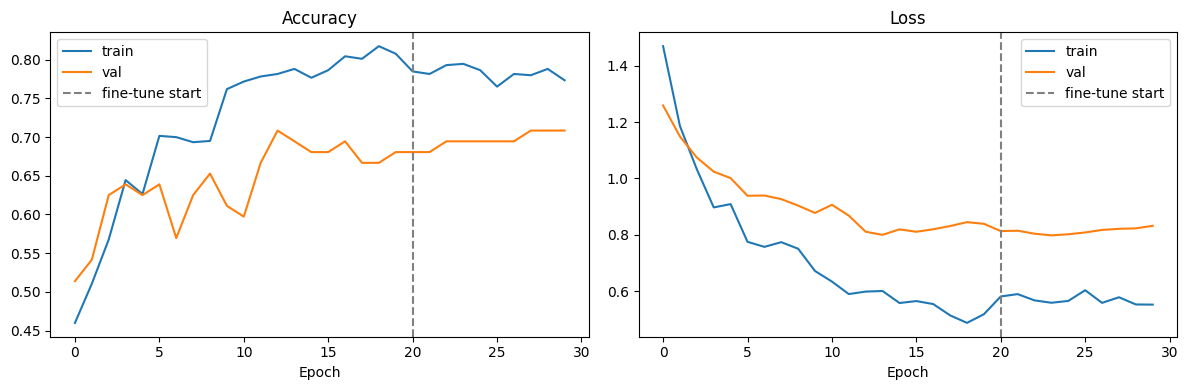


--- Final Classification Report (4-class, test set) ---
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.68      0.69      0.69       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.58      0.49      0.53        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.68      0.73      0.71        90

                                        accuracy                           0.72       315
                                       macro avg       0.74      0.72      0.73       315
                                    weighted avg       0.72      0.72      0.72       315



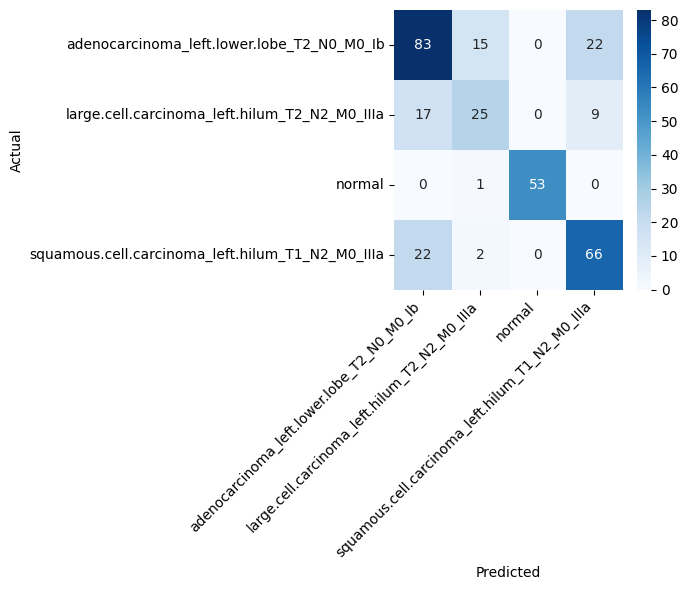

Saved model.


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ---------------------------------------------------------
# 1. Dataset setup
# ---------------------------------------------------------
if not os.path.exists('dataset'):
    os.system('kaggle datasets download -d mohamedhanyyy/chest-ctscan-images')
    os.system('unzip -q chest-ctscan-images.zip -d dataset')

img_height, img_width = 224, 224
batch_size = 32
seed = 42

train_dir = 'dataset/Data/train'
val_dir   = 'dataset/Data/valid'
test_dir  = 'dataset/Data/test'

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, seed=seed, image_size=(img_height, img_width), batch_size=batch_size, shuffle=True
)
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, seed=seed, image_size=(img_height, img_width), batch_size=batch_size, shuffle=False
)
raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, seed=seed, image_size=(img_height, img_width), batch_size=batch_size, shuffle=False
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# ---------------------------------------------------------
# 2. Class weights (fixes the large.cell.carcinoma recall=0 issue)
# ---------------------------------------------------------
train_labels = np.concatenate([y.numpy() for _, y in raw_train_ds], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000, seed=seed).prefetch(AUTOTUNE)
val_ds   = raw_val_ds.cache().prefetch(AUTOTUNE)
test_ds  = raw_test_ds.cache().prefetch(AUTOTUNE)

# ---------------------------------------------------------
# 3. Augmentation
# ---------------------------------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# ---------------------------------------------------------
# 4. Model
# ---------------------------------------------------------
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False, weights='imagenet', input_shape=(img_height, img_width, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

phase1_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_loss', save_best_only=True)
]

print("\n=== Phase 1: training the head (backbone frozen) ===")
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=phase1_callbacks
)

# ---------------------------------------------------------
# 5. Phase 2: light fine-tuning
# ---------------------------------------------------------
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

phase2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_phase2.keras', monitor='val_loss', save_best_only=True)
]

print("\n=== Phase 2: fine-tuning ===")
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=phase2_callbacks
)
# ---------------------------------------------------------
# 6. Plot Accuracy and Loss curves
# ---------------------------------------------------------
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(combine_history(history1, history2, 'accuracy'), label='train')
axes[0].plot(combine_history(history1, history2, 'val_accuracy'), label='val')
axes[0].axvline(len(history1.history['accuracy']), color='gray', linestyle='--', label='fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(combine_history(history1, history2, 'loss'), label='train')
axes[1].plot(combine_history(history1, history2, 'val_loss'), label='val')
axes[1].axvline(len(history1.history['loss']), color='gray', linestyle='--', label='fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
# ---------------------------------------------------------
# 6. Evaluation
# ---------------------------------------------------------
y_true, y_pred, y_prob = [], [], []
for images, labels in test_ds:
    probs = model.predict_on_batch(images)
    y_pred.extend(np.argmax(probs, axis=1))
    y_prob.extend(probs)
    y_true.extend(labels.numpy())

y_true, y_pred, y_prob = np.array(y_true), np.array(y_pred), np.array(y_prob)

print("\n--- Final Classification Report (4-class, test set) ---")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

model.save('lung_cancer_model_final.keras')
print("Saved model.")